# Napelemes ETL-szimuláció – Debrecen, Déli Gazdasági Övezet, 2023–2025

***Készítette: Tátrai Csaba Attila***

## 0. Környezet beállítása (Setup)

**Intelligens Naplózás (Logging) beállítása**
A Jupyter Notebook alapértelmezésben a standard hibacsatornára (`stderr`) irányítja a beépített Python logger üzeneteit, ami miatt az üzemszerű működést jelző `INFO` szintű üzenetek is zavaró, pirosas/rózsaszínes "warning" háttérrel jelennek meg. 

Az alábbi kód egy egyedi formázót (`ColorFormatter`) alkalmaz, amely a normál kimenetre (`stdout`) irányítja a logokat, és a **hiba súlyossága alapján színezi** azokat (INFO = zöld, WARNING = sárga, ERROR = piros). Ezzel biztosítjuk a tiszta kimenetet, anélkül, hogy a fontos hibák elkerülnék a figyelmünket.

<div style="background-color: #fff1f2; border-left: 5px solid #e11d48; padding: 12px 16px; border-radius: 4px; margin: 12px 0;">
<b>⚠️ FONTOS BIZTONSÁGI MEGJEGYZÉS: MIRE NINCS HATÁSSAL EZ A KÓD?</b><br>
Ez a színezés <b>kizárólag</b> a Python <code>logging</code> modulján keresztül küldött üzenetekre vonatkozik. <br>
Két dolog továbbra is a Jupyter megszokott, figyelemfelkeltő piros/rózsaszín hátterével fog megjelenni:
<ul style="margin-top: 4px; margin-bottom: 0;">
    <li><b>Python kivételek (Exceptions):</b> Ha a kód szintaktikai vagy futásidejű hiba miatt összeomlik (pl. <code>KeyError</code>, <code>TypeError</code>).</li>
    <li><b>Külső könyvtárak figyelmeztetései:</b> A <code>warnings</code> modul által generált üzenetek (pl. a Pandas <code>FutureWarning</code> üzenetei).</li>
</ul>
Emiatt <b>garantáltan nem maradsz le semmilyen kritikus hibáról</b>, a környezet 100%-ig biztonságos marad!
</div>

In [5]:
import logging
import sys
sys.path.insert(0, 'src')

class ColorFormatter(logging.Formatter):
    """Egyedi formázó, ami log-szint alapján színezi az üzeneteket."""
    GREEN = "\033[32m"
    YELLOW = "\033[33m"
    RED = "\033[31m"
    RESET = "\033[0m"

    # Szabályok: Melyik szint milyen színt kapjon
    FORMATS = {
        logging.DEBUG:    f"%(asctime)s  %(levelname)-8s  %(message)s",
        logging.INFO:     f"{GREEN}%(asctime)s  %(levelname)-8s{RESET}  %(message)s",
        logging.WARNING:  f"{YELLOW}%(asctime)s  %(levelname)-8s{RESET}  %(message)s",
        logging.ERROR:    f"{RED}%(asctime)s  %(levelname)-8s{RESET}  %(message)s",
        logging.CRITICAL: f"{RED}%(asctime)s  %(levelname)-8s{RESET}  %(message)s"
    }

    def format(self, record):
        log_fmt = self.FORMATS.get(record.levelno)
        formatter = logging.Formatter(log_fmt, datefmt="%H:%M:%S")
        return formatter.format(record)

# Logger alaphelyzetbe állítása és az egyedi formázó beállítása
logger = logging.getLogger()
logger.setLevel(logging.INFO)

# Töröljük a Jupyter esetleges korábbi (zavaró) logger beállításait
if logger.hasHandlers():
    logger.handlers.clear()

# Új kimeneti csatorna (stdout) felépítése az okos színezővel
handler = logging.StreamHandler(sys.stdout)
handler.setFormatter(ColorFormatter())
logger.addHandler(handler)

## 1. Adatelőkészítés

### 1.1 Adat letöltése

Az OpenMeteo historikus API-ból letöltjük **Debrecen, Déli Gazdasági Övezet** (47.4728°N, 21.6145°E) **2023–2025-ös** óránkénti időjárásadatait: globális (GHI), direkt normál (DNI) és diffúz (DHI) irradianciát, léghőmérsékletet és szélsebességet. Az adatok DuckDB adatbázisba (`solar_data.duckdb`, `weather_data` tábla) kerülnek. A `load_weather_data()` idempotens és évenként fut: ha egy adott év adatai már megvannak, az API-hívás elmarad.

In [6]:
from data_loader import load_weather_data, get_weather_dataframe
load_weather_data()          # letöltés + DB írás (első futtatásnál)
df_weather = get_weather_dataframe()   # DataFrame a pvlib pipeline-hoz

18:38:40  INFO      OpenMeteo API lekérés – 1. kísérlet (koordináták: 47.4728, 21.6145, év: 2023)
18:38:40  INFO      API válasz megérkezett, rekordok száma: 8760
18:38:44  INFO      Nincs NaN érték – adatminőség rendben.
18:38:44  INFO      Sorok száma: 8760 (teljes 2023. év, óránkénti) – OK
18:38:44  INFO      Nincs új adat – az adatbázis már naprakész.
18:38:44  INFO      2024. év: már 8784 sor van – letöltés kihagyva (force_reload=True-val kényszeríthető újra).
18:38:44  INFO      2025. év: már 8760 sor van – letöltés kihagyva (force_reload=True-val kényszeríthető újra).
18:38:44  INFO      weather_data betöltve: 26304 sor, 2023-01-01T01:00:00+01:00 – 2026-01-01T00:00:00+01:00


### 1.2 Dataset ellenőrzése

Az adatbázisba kerülés után közvetlenül SQL-lel ellenőrizzük a `weather_data` tábla tartalmát – a Python-réteg megkerülésével, közvetlenül a tárolt értékeken.

**Sorszám és időhatárok:** megerősítjük, hogy mind a 26 304 órányi adat megérkezett (2023: 8760, 2024: 8784 szökőév, 2025: 8760), és az idősor pontosan 2023-01-01-től 2026-01-01-ig tart (az utolsó adat UTC szempontból a 2025-12-31 23:00 UTC sor, ami helyi időben 2026-01-01T00:00:00+01:00).

**DST-átmenetek:** a tavaszi átmenetnél (pl. 2023. március 26.) a `02:00` timestamp hiányzik – az óra azon a napon 02:00-ról 03:00-ra ugrott, ez az időpont fizikailag nem létezett. Az őszi átmenetnél (pl. 2023. október 29.) a `02:00:00+02:00` és `02:00:00+01:00` sorok külön szerepelnek: az eltérő UTC offset egyértelműen megkülönbözteti a visszaforgatás előtti és utáni órát. Mindkét eset helyes tárolást mutat.

**Fizikai minimum:** megerősítjük, hogy az összes sugárzási érték és a szélsebesség minimuma 0 – a `data_loader.py` `clip(lower=0)` lépése érvényesült.

In [7]:
import duckdb
import pandas as pd

con = duckdb.connect("data/solar_data.duckdb", read_only=True)

# 1. Sorszam es idohatarok
print(con.execute(
    "SELECT COUNT(*) AS sorok, MIN(timestamp) AS elso, MAX(timestamp) AS utolso "
    "FROM weather_data"
).df())

# 2. Elso es utolso 3 sor
print(con.execute("SELECT * FROM weather_data ORDER BY timestamp LIMIT 3").df())
print(con.execute("SELECT * FROM weather_data ORDER BY timestamp DESC LIMIT 3").df())

# 3. DST-atmenetek korvetlen kornyeke (TIMESTAMPTZ: UTC-ben tarolva, Budapestre konvertalva)
for day in ("2023-03-26", "2023-10-29"):
    print(con.execute(
        "SELECT timestamp AT TIME ZONE 'Europe/Budapest' AS local_ts, ghi, temp_air"
        " FROM weather_data"
        f" WHERE timestamp::DATE = '{day}'::DATE"
        " ORDER BY timestamp"
    ).df())

# 4. Statisztika - negativ ertek nem lehet
print(con.execute(
    "SELECT MIN(ghi) AS ghi_min, MIN(dni) AS dni_min, "
    "       MIN(dhi) AS dhi_min, MIN(wind_speed) AS ws_min "
    "FROM weather_data"
).df())

con.close()

   sorok                      elso                    utolso
0  26304 2023-01-01 01:00:00+01:00 2026-01-01 00:00:00+01:00
                  timestamp  ghi  dni  dhi  temp_air  wind_speed
0 2023-01-01 01:00:00+01:00  0.0  0.0  0.0       7.7        3.51
1 2023-01-01 02:00:00+01:00  0.0  0.0  0.0       7.5        4.02
2 2023-01-01 03:00:00+01:00  0.0  0.0  0.0       7.3        4.14
                  timestamp  ghi  dni  dhi  temp_air  wind_speed
0 2026-01-01 00:00:00+01:00  0.0  0.0  0.0      -3.6        3.54
1 2025-12-31 23:00:00+01:00  0.0  0.0  0.0      -3.5        3.43
2 2025-12-31 22:00:00+01:00  0.0  0.0  0.0      -3.5        3.09
              local_ts    ghi  temp_air
0  2023-03-26 00:00:00    0.0       8.8
1  2023-03-26 01:00:00    0.0       8.4
2  2023-03-26 03:00:00    0.0       7.9
3  2023-03-26 04:00:00    0.0       7.4
4  2023-03-26 05:00:00    0.0       6.8
5  2023-03-26 06:00:00    0.0       6.3
6  2023-03-26 07:00:00   10.0       6.4
7  2023-03-26 08:00:00  119.0       8.

### 1.3 Ellenőrzés: tisztítandó-e a kapott adathalmaz?

A `data_loader.py` már garantál néhány alapvető tulajdonságot (nincs NaN, nincs negatív sugárzási érték, 26 304 sor), ezek azonban a saját betöltő logikánk által nyújtott garanciák. Ez a cella az adatbázisban ténylegesen tárolt adatot ellenőrzi függetlenül, négy szempontból.

**Fizikai konzisztencia (GHI ≥ DHI):** a `clip(lower=0)` önmagában nem garantálja ezt – hibás változónév-mapping vagy API-hiba esetén is lehetne GHI < DHI anélkül, hogy NaN vagy negatív érték keletkezne. Az ellenőrzés 0 ilyen esetet talált.

**Kiugró értékek:** az OpenMeteo ERA5 reanalízis alapú adatokat közöl, amelyeknél elvétve előfordulhat modellhiba. Ha pl. GHI = 1800 W/m² szerepelt volna az adatban, a pvlib pipeline hiba nélkül lefutott volna, csak irreális eredménnyel. Az ellenőrzés 0 kiugró értéket talált.

**Időbeli folytonosság:** az adatbázis UTC-ben tárolja a timestampokat; a `tz_convert("Europe/Budapest")` csupán megjelenítési konverzió, az egymást követő sorok valódi időkülönbsége változatlanul 1 óra marad. Ezért a DST-átmenetek nem okoznak látszólagos időbeli ugrást – a mérés 0 nem-1-órás lépést talált.

**Következtetés:** az adathalmaz tisztítás nélkül alkalmas a PV szimulációra.

In [8]:
import duckdb
import pandas as pd
import numpy as np

# DuckDB a TIMESTAMPTZ-t UTC-kent adja vissza; tz_convert-tel helyi idore hozzuk
with duckdb.connect("data/solar_data.duckdb", read_only=True) as con:
    df = con.execute(
        "SELECT timestamp, ghi, dni, dhi, temp_air, wind_speed "
        "FROM weather_data ORDER BY timestamp"
    ).df()

df["timestamp"] = df["timestamp"].dt.tz_convert("Europe/Budapest")

print("=== 1. Alapstatisztika ===")
print(df[["ghi", "dni", "dhi", "temp_air", "wind_speed"]].describe().round(2))

print("\n=== 2. Fizikai konzisztencia: GHI < DHI esetek ===")
bad = df[df["ghi"] < df["dhi"]]
print(f"Erintett sorok: {len(bad)}")
if len(bad):
    print(bad[["timestamp", "ghi", "dhi"]].head())

print("\n=== 3. Kiemelkedo ertekek ===")
print(f"GHI > 1200 W/m2    : {(df['ghi'] > 1200).sum()} sor")
print(f"DNI > 1000 W/m2    : {(df['dni'] > 1000).sum()} sor")
print(f"temp_air < -30 C   : {(df['temp_air'] < -30).sum()} sor")
print(f"temp_air > 45 C    : {(df['temp_air'] > 45).sum()} sor")
print(f"wind_speed > 30 m/s: {(df['wind_speed'] > 30).sum()} sor")

print("\n=== 4. Idobeli folytonossag (gaps) ===")
diffs    = df["timestamp"].diff().dropna()
expected = pd.Timedelta("1h")
gaps     = diffs[diffs != expected]
print(f"Nem 1 oras lepesek szama: {len(gaps)}")
if len(gaps):
    print(gaps)

print("\n=== 5. NaN ellenorzes ===")
print(df.isna().sum())

=== 1. Alapstatisztika ===
            ghi       dni       dhi  temp_air  wind_speed
count  26304.00  26304.00  26304.00  26304.00    26304.00
mean     157.41    188.02     55.74     12.65        2.84
std      234.02    275.18     75.49      9.08        1.51
min        0.00      0.00      0.00     -8.30        0.00
25%        0.00      0.00      0.00      5.20        1.73
50%        6.00      0.00      6.00     12.40        2.56
75%      263.00    369.80    101.00     19.70        3.75
max      925.00    888.20    434.00     37.40       10.78

=== 2. Fizikai konzisztencia: GHI < DHI esetek ===
Erintett sorok: 0

=== 3. Kiemelkedo ertekek ===
GHI > 1200 W/m2    : 0 sor
DNI > 1000 W/m2    : 0 sor
temp_air < -30 C   : 0 sor
temp_air > 45 C    : 0 sor
wind_speed > 30 m/s: 0 sor

=== 4. Idobeli folytonossag (gaps) ===
Nem 1 oras lepesek szama: 0

=== 5. NaN ellenorzes ===
timestamp     0
ghi           0
dni           0
dhi           0
temp_air      0
wind_speed    0
dtype: int64


### 1.4 Bemeneti időjárási adatok

Az OpenMeteo API három óránkénti idősorát – globális vízszintes sugárzás (GHI), levegőhőmérséklet és szélsebesség – tároltuk a `weather_data` táblában. Ezek alkotják a pvlib pipeline inputját, és egyben egy prediktív ML-modell természetes **feature-vektorát** is:

<table style="width: 100%; border-collapse: collapse; font-family: sans-serif;">
  <thead>
    <tr style="background-color: #A81022; color: #ffffff; text-align: left;">
      <th style="padding: 10px; border: 1px solid #ddd;">Feature</th>
      <th style="padding: 10px; border: 1px solid #ddd;">Fizikai szerepe</th>
      <th style="padding: 10px; border: 1px solid #ddd;">Miért ML-feature?</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: #f9f9f9;">
      <td style="padding: 10px; border: 1px solid #ddd;">GHI [W/m²]</td>
      <td style="padding: 10px; border: 1px solid #ddd;">elsődleges hajtóerő</td>
      <td style="padding: 10px; border: 1px solid #ddd;">legerősebb korreláció a P_ac-kal</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="padding: 10px; border: 1px solid #ddd;">Léghőmérséklet [°C]</td>
      <td style="padding: 10px; border: 1px solid #ddd;">cellatermodegradáció</td>
      <td style="padding: 10px; border: 1px solid #ddd;">nemlineáris nyári veszteség</td>
    </tr>
    <tr style="background-color: #f9f9f9;">
      <td style="padding: 10px; border: 1px solid #ddd;">Szélsebesség [m/s]</td>
      <td style="padding: 10px; border: 1px solid #ddd;">hűtési hatékonyság</td>
      <td style="padding: 10px; border: 1px solid #ddd;">mérsékli a hőstresszt</td>
    </tr>
  </tbody>
</table>

Ez a három változó egy valós IoT-rendszerben szenzorjelként érkezne; a pvlib-szimuláció szintetikus tanítóadatot generál belőlük egy prediktív modellhez.

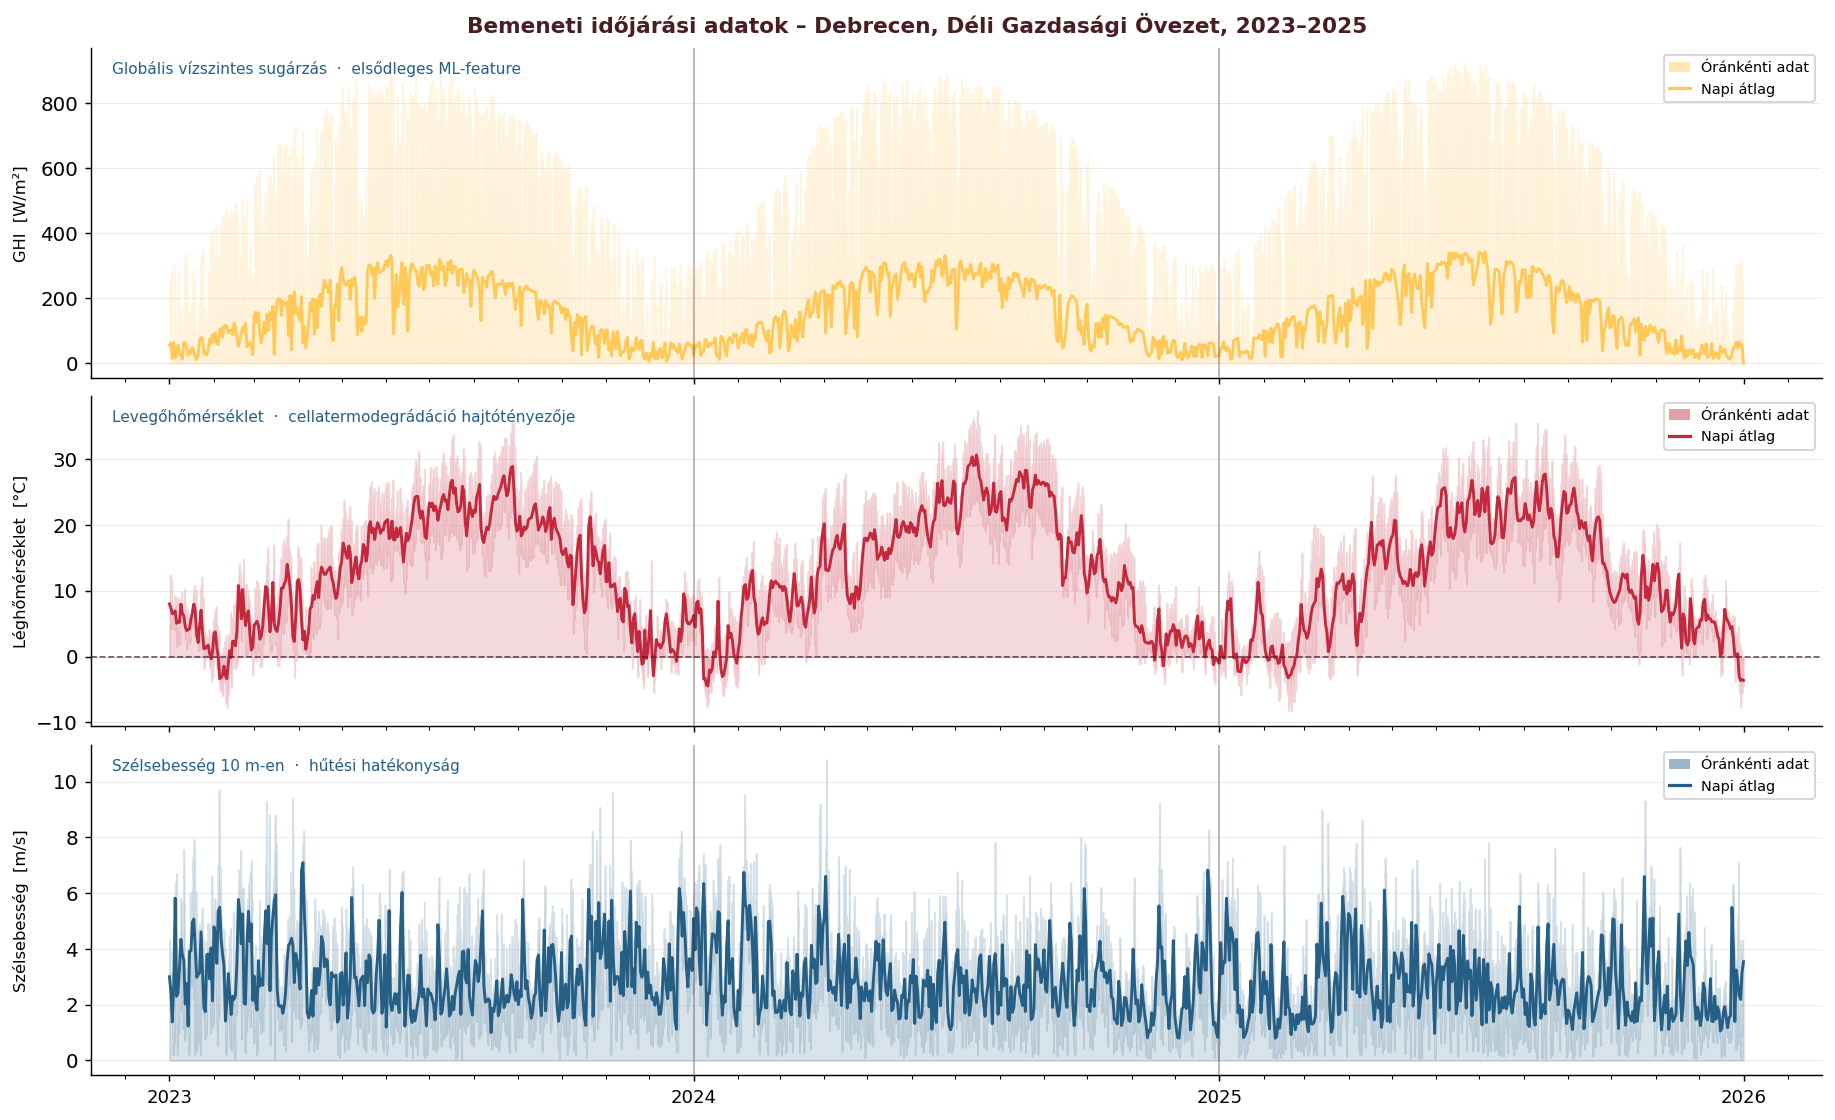

In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from config import C_WEATHER, C_BASE, MPL_DEFAULTS, LOCATION_NAME, START_DATE, END_DATE
plt.rcParams.update(MPL_DEFAULTS)
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

start_yr, end_yr = START_DATE[:4], END_DATE[:4]

fig, axes = plt.subplots(3, 1, figsize=(14, 8.5), sharex=True, layout="constrained")
fig.suptitle(
    f"Bemeneti időjárási adatok – {LOCATION_NAME}, {start_yr}–{end_yr}",
    fontsize=12, fontweight="bold", color=C_BASE["title"]
)

dw       = df_weather.copy()
dw_daily = dw.resample("D").mean()

panels = [
    ("ghi",        axes[0], C_WEATHER["ghi"],
     "GHI  [W/m²]",         "Globális vízszintes sugárzás  ·  elsődleges ML-feature"),
    ("temp_air",   axes[1], C_WEATHER["temp"],
     "Léghőmérséklet  [°C]", "Levegőhőmérséklet  ·  cellatermodegrádáció hajtótényezője"),
    ("wind_speed", axes[2], C_WEATHER["wind"],
     "Szélsebesség  [m/s]",  "Szélsebesség 10 m-en  ·  hűtési hatékonyság"),
]

for col, ax, color, ylabel, subtitle in panels:
    ax.fill_between(dw.index, dw[col], alpha=0.18, color=color)
    ax.plot(dw_daily.index, dw_daily[col], color=color, lw=1.6)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.text(0.012, 0.96, subtitle, transform=ax.transAxes,
            va="top", fontsize=8.5, color=C_BASE["text_lt"])
    ax.grid(axis="y", lw=0.4, alpha=0.35)
    ax.spines[["top", "right"]].set_visible(False)

    legend_handles = [
        Patch(facecolor=color, alpha=0.45, label="Óránkénti adat"),
        Line2D([0], [0], color=color, lw=1.8, label="Napi átlag"),
    ]
    ax.legend(handles=legend_handles, fontsize=8, loc="upper right",
              framealpha=0.85, handlelength=1.4)

axes[1].axhline(0, color=C_BASE["neutral"], lw=0.9, ls="--", alpha=0.8)  # fagyáshatár

# ── Évhatárok: függőleges elválasztó mindhárom panelen ──────────────────────
tz = dw.index.tz
for yr in range(int(start_yr) + 1, int(end_yr) + 1):
    boundary = pd.Timestamp(yr, 1, 1, tz=tz)
    for ax in axes:
        ax.axvline(boundary, color=C_BASE["neutral_dk"], lw=1.0, ls="-",
                   alpha=0.35, zorder=3)

# X-tengely: évek neve, hónap minor tick-ek
axes[2].xaxis.set_major_locator(mdates.YearLocator())
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[2].xaxis.set_minor_locator(mdates.MonthLocator())
axes[2].tick_params(axis="x", which="major", labelsize=10, pad=4)

fig.align_ylabels(axes)
plt.show()


## 2. Szimuláció

A `pv_calculator.py` modul valósítja meg a feladatkiírás **Python teljesítményszámoló komponensét**. Beolvassa a `weather_data` táblát, a `pvlib` könyvtár segítségével elvégzi a teljes szimulációt, és az eredményeket a `pv_results` táblába írja.

### 2.1 Szimuláció futtatása

A számítás a következő napelemrendszerre vonatkozik:

| Paraméter | Érték |
|---|---|
| Panel | Jinko Solar Tiger Neo N-type 54HL4R-B (430 W) |
| Panelek száma | 10 db → 4300 W DC csúcs |
| Inverter | 3000 W (ILR = 1,43 → nyári clipping) |
| Dőlésszög | 30° |
| Helyszín | Debrecen, Déli Gazdasági Övezet (47.4728°N, 21.6145°E) |
| Időszak | 2023–2025 (3 év; újrafuttatáshoz: ) |

In [10]:
from pv_calculator import run_pv_simulation, get_pv_dataframe, PDC0_TOTAL, PDC0_INV

df_pv = run_pv_simulation(force_reload=True)  # újraszámítás: 3 év + degradáció + p_ac_net DuckDB-be

18:38:55  INFO      PV szimuláció indítása...
18:38:55  INFO      weather_data betöltve: 26304 sor, 2023-01-01T01:00:00+01:00 – 2026-01-01T00:00:00+01:00
18:38:55  INFO      Szolárpozíció kiszámítva (26304 időpont).
18:38:55  INFO      POA irradiancia kiszámítva (haydavies). Max: 1013.1 W/m², éves összeg: 4937 kWh/m².
18:38:55  INFO      Cellahőmérséklet kiszámítva (pvsyst). Max: 59.2 °C, átlag (nappali): 24.5 °C.
18:38:55  INFO      DC teljesítmény kiszámítva (pvwatts_dc). Max: 4209.5 W, éves összeg: 20662 kWh.
18:38:55  INFO      AC teljesítmény kiszámítva (inverter.pvwatts).
18:38:55  INFO        Éves AC termelés      : 18755.4 kWh
18:38:55  INFO        Fajlagos hozam        : 4361.7 kWh/kWp
18:38:55  INFO        Kapacitásfaktor       : 49.79 %
18:38:55  INFO        Clipping veszteség    : 1072148.9 Wh
18:38:55  INFO        Csúcs AC teljesítmény : 2880.0 W @ 2023-01-12T12:00:00+01:00
18:38:55  INFO        Degradációs faktor 2023: 0.99000 (rendszerveszteséggel együtt: 0.85924)
18:38:

### 2.2 Eredmény ellenőrzése

Gyors sanity check: sorok száma, időhatárok, NaN-értékek és a `p_ac` fizikai értékkészlete. A `p_ac` minimuma 0 kell legyen (a negatív inverter-szivárgási értékeket a kód nullára vágja), maximuma az inverter 3 kW-os clipping határán vagy alatt.

In [11]:
print(f"Sorok száma    : {len(df_pv)}")
print(f"Első időpont   : {df_pv.index[0]}")
print(f"Utolsó időpont : {df_pv.index[-1]}")
print()
print("NaN értékek:")
print(df_pv.isna().sum())
print()
print(f"p_ac  min : {df_pv['p_ac'].min():.4f} W   (negatív nem lehet)")
print(f"p_ac  max : {df_pv['p_ac'].max():.1f} W")
print(f"p_dc  max : {df_pv['p_dc'].max():.1f} W")
print()
print("Első nappali sorok (p_ac > 0):")
print(df_pv[df_pv["p_ac"] > 0].head(3).round(2))

Sorok száma    : 26304
Első időpont   : 2023-01-01 01:00:00+01:00
Utolsó időpont : 2026-01-01 00:00:00+01:00

NaN értékek:
poa_global       0
temp_cell        0
p_dc             0
p_ac             0
p_ac_net         0
energy_loss_w    0
dtype: int64

p_ac  min : 0.0000 W   (negatív nem lehet)
p_ac  max : 2880.0 W
p_dc  max : 4209.5 W

Első nappali sorok (p_ac > 0):
                           poa_global  temp_cell     p_dc     p_ac  p_ac_net  \
timestamp                                                                      
2023-01-01 08:00:00+01:00       30.73       7.15   139.21   118.97    102.23   
2023-01-01 09:00:00+01:00      228.94      13.18  1019.32   977.77    840.14   
2023-01-01 10:00:00+01:00      386.07      18.32  1693.36  1629.85   1400.44   

                           energy_loss_w  
timestamp                                 
2023-01-01 08:00:00+01:00          16.75  
2023-01-01 09:00:00+01:00         137.63  
2023-01-01 10:00:00+01:00         229.41  


## 3. További vizualizációk

### 3.0 Hónap × napszak hőtérkép

A validált modell által produkált energia időbeli szerkezete szezonális és napszaki bontásban.

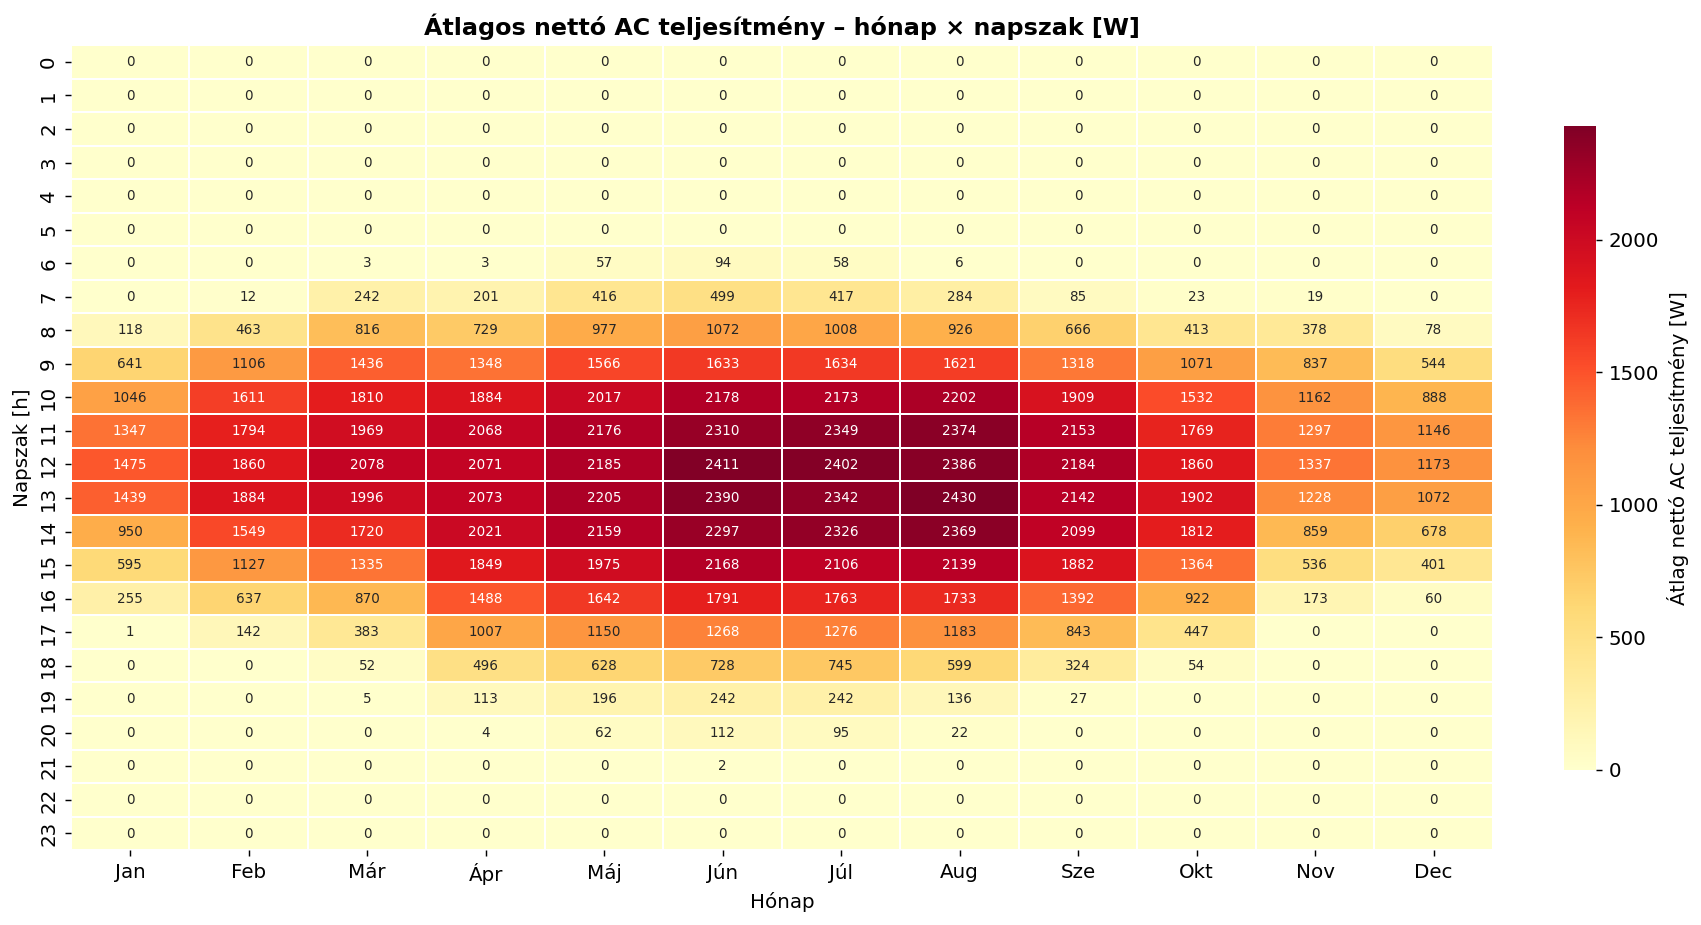

In [12]:
import math
from config import C_HEATMAP, MPL_DEFAULTS
plt.rcParams.update(MPL_DEFAULTS)
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from config import DETAILED_SYSTEM_LOSSES

MONTH_HU = [
    "Jan", "Feb", "Már", "Ápr", "Máj", "Jún",
    "Júl", "Aug", "Sze", "Okt", "Nov", "Dec",
]
derate_live = math.prod(1.0 - v for v in DETAILED_SYSTEM_LOSSES.values())

pivot = df_pv.assign(
    p_ac_net=df_pv["p_ac"] * derate_live,
    _month=df_pv.index.month,
    _hour=df_pv.index.hour,
).pivot_table(values="p_ac_net", index="_hour", columns="_month", aggfunc="mean")
pivot.columns = MONTH_HU
pivot.index.name = "Napszak [h]"

fig, ax = plt.subplots(figsize=(13, 7), layout="constrained")
sns.heatmap(
    pivot, ax=ax, cmap="YlOrRd", linewidths=0.2,
    cbar_kws={"label": "Átlag nettó AC teljesítmény [W]", "shrink": 0.8},
    annot=True, fmt=".0f", annot_kws={"size": 7.5},
)
ax.set_title("Átlagos nettó AC teljesítmény – hónap × napszak [W]", fontweight="bold")
ax.set_xlabel("Hónap")

plt.show()

<a id="viz-scatter"></a>

### 3.1 DC modell-validáció

A szimulációs eredmények hitelességének alapja. A két panel együtt mutatja a pvlib `pvwatts_dc` lépésének viselkedését.

**Bal panel – teljes adatfelhő:** az összes nappali adatpont (POA > 50 W/m²) POA-irradiancia szerint színezve (YlOrRd colormap). Az arany–narancs–vörös gradiens megmutatja, hogy erős sugárzásnál (vörös) az azonos hőmérsékletű pontokhoz nagyobb DC teljesítmény tartozik – a POA és a hőmérséklet együttes hatása itt egyetlen felhőben látható.

**Jobb panel – binelt regresszió:** ugyanezek a pontok négy szűk POA-tartományban (±50 W/m² bin) csoportosítva. Binenként lineáris regresszió méri a hőmérsékleti meredekséget. A magasabb POA-s binek (500–900 W/m²) γ értéke az adatlap −0,30 %/K referenciáját közelíti; az alacsony (300 W/m²) bin szignifikánsan eltér (mért: ~−0,15 %/K), ami fizikailag várható: kis irradiancánál a cellahőmérséklet-emelkedés abszolút értéke csekély, a regresszió torzít.

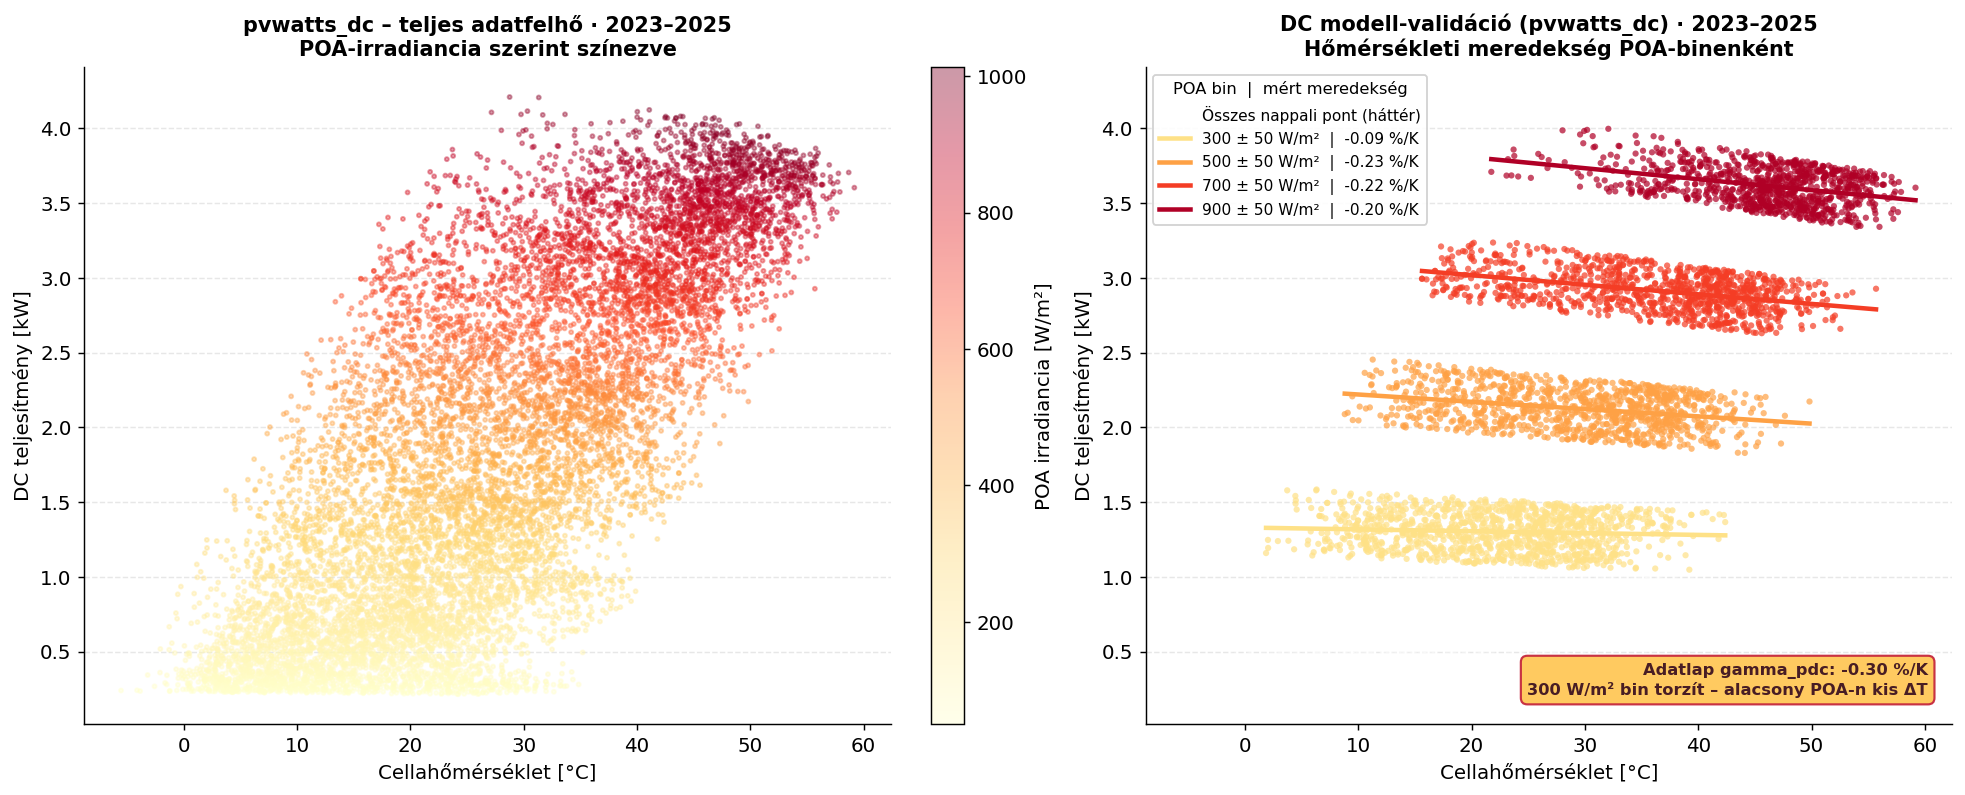


POA-binenként mért gamma_pdc:
  300 ± 50 W/m²         : -0.095 %/K  (n = 1172)
  500 ± 50 W/m²         : -0.230 %/K  (n = 1057)
  700 ± 50 W/m²         : -0.221 %/K  (n = 1019)
  900 ± 50 W/m²         : -0.203 %/K  (n = 919)
  Adatlap referencia    : -0.300 %/K


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from config import GAMMA_PDC, C_BASE, MPL_DEFAULTS, START_DATE, END_DATE
plt.rcParams.update(MPL_DEFAULTS)

daytime = df_pv[df_pv["poa_global"] > 50].copy()
_period = f"{START_DATE[:4]}–{END_DATE[:4]}"

poa_bins = [
    (250, 350, "300 ± 50 W/m²"),
    (450, 550, "500 ± 50 W/m²"),
    (650, 750, "700 ± 50 W/m²"),
    (850, 950, "900 ± 50 W/m²"),
]
bin_colors    = plt.cm.YlOrRd(np.linspace(0.2, 0.9, len(poa_bins)))
gamma_pdc_pct = GAMMA_PDC * 100

fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 6), layout="constrained")

# ── Bal panel: teljes adatfelhő – POA-irradiancia szerint színezve ────────────────────
sc = axL.scatter(daytime["temp_cell"], daytime["p_dc"] / 1000,
                 c=daytime["poa_global"], cmap="YlOrRd",
                 alpha=0.40, s=5, rasterized=True, zorder=2)
plt.colorbar(sc, ax=axL).set_label("POA irradiancia [W/m²]")
axL.set_xlabel("Cellahőmérséklet [°C]")
axL.set_ylabel("DC teljesítmény [kW]")
axL.set_title(
    f"pvwatts_dc – teljes adatfelhő · {_period}" + chr(10)
    + "POA-irradiancia szerint színezve",
    fontweight="bold", fontsize=11.5)
axL.yaxis.grid(True, alpha=0.3, linestyle="--")
axL.set_axisbelow(True)

# ── Jobb panel: POA-binenként regresszió ─────────────────────────────────────
axR.scatter(daytime["temp_cell"], daytime["p_dc"] / 1000,
            c=C_BASE["bg"], alpha=0.18, s=4, rasterized=True, zorder=1,
            label="Összes nappali pont (háttér)")

slope_results = []
for (lo, hi, label), color in zip(poa_bins, bin_colors):
    subset = daytime[(daytime["poa_global"] >= lo) & (daytime["poa_global"] < hi)]
    if len(subset) < 5:
        continue
    x = subset["temp_cell"].values
    y = subset["p_dc"].values / 1000
    axR.scatter(x, y, color=color, alpha=0.70, s=12, zorder=3, edgecolors="none")
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 50)
    y_mid  = slope * np.median(x) + intercept
    pct_k  = (slope / y_mid) * 100 if y_mid > 0 else 0.0
    axR.plot(x_line, slope * x_line + intercept,
             color=color, linewidth=2.5, zorder=4,
             label=f"{label}  |  {pct_k:+.2f} %/K")
    slope_results.append((label, pct_k, len(subset)))

_ann = (f"Adatlap gamma_pdc: {gamma_pdc_pct:+.2f} %/K"
        + chr(10) + "300 W/m² bin torzít – alacsony POA-n kis ΔT")
axR.text(0.97, 0.04, _ann,
         transform=axR.transAxes, fontsize=9, ha="right", va="bottom",
         fontweight="bold", color=C_BASE["text_dk"],
         bbox=dict(boxstyle="round,pad=0.4", facecolor=C_BASE["ann_fill"],
                   edgecolor=C_BASE["ann_edge"], linewidth=1.2, alpha=0.95))

axR.set_xlabel("Cellahőmérséklet [°C]")
axR.set_ylabel("DC teljesítmény [kW]")
axR.set_title(
    f"DC modell-validáció (pvwatts_dc) · {_period}" + chr(10)
    + "Hőmérsékleti meredekség POA-binenként",
    fontweight="bold", fontsize=11.5)
axR.legend(framealpha=0.88, fontsize=8.5,
           title="POA bin  |  mért meredekség", title_fontsize=9,
           loc="upper left")
axR.yaxis.grid(True, alpha=0.3, linestyle="--")
axR.set_axisbelow(True)

plt.show()

print("")
print("POA-binenként mért gamma_pdc:")
for label, pct, n in slope_results:
    print(f"  {label:22s}: {pct:+.3f} %/K  (n = {n})")
print(f"  Adatlap referencia    : {gamma_pdc_pct:+.3f} %/K")

<a id="viz-idosor"></a>

### 3.2 Napi termelés, éves idősor

Napi összesített nettó AC termelés [kWh] és 14 napos mozgóátlag. Zöld: növekvő félév (jan. 1. – jún. 21.), piros: csökkenő félév (jún. 21. – dec. 21.). A nyári szórás az időjárás-variabilitást mutatja.

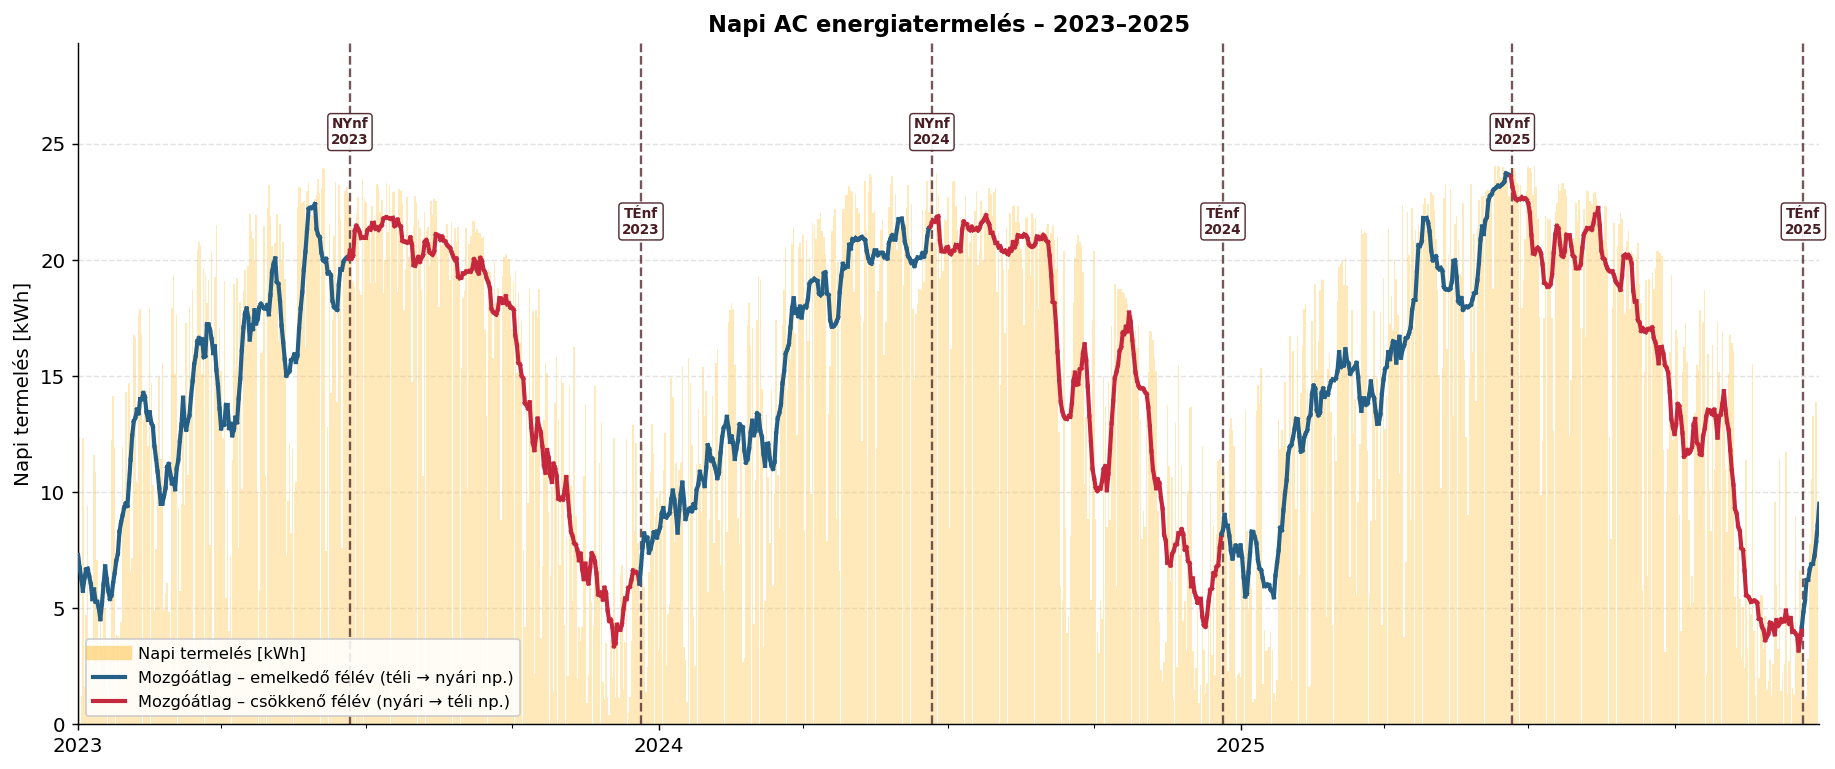

In [14]:
import datetime
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import math
from config import TIMEZONE, DETAILED_SYSTEM_LOSSES, C_DAILY, C_BASE, MPL_DEFAULTS

plt.rcParams.update(MPL_DEFAULTS)

# ── Adatok előkészítése ───────────────────────────────────────────────────────
derate_live = math.prod(1.0 - v for v in DETAILED_SYSTEM_LOSSES.values())
daily_kwh  = (df_pv["p_ac"] * derate_live).resample("D").sum() / 1000
daily_kwh = daily_kwh[daily_kwh.index.year <= 2025]

rolling_14 = daily_kwh.rolling(14, center=True, min_periods=7).mean()
all_years  = sorted(daily_kwh.index.year.unique())

# ── Napfordulók minden évre ───────────────────────────────────────────────────
solstices = []
for yr in all_years:
    summer = pd.Timestamp(datetime.date(yr, 6, 21)).tz_localize(TIMEZONE)
    winter = pd.Timestamp(datetime.date(yr, 12, 21)).tz_localize(TIMEZONE)
    solstices.append((summer, "nyári", yr))
    solstices.append((winter, "téli",  yr))
solstices.sort(key=lambda x: x[0])

SOLSTICE_COLOR = C_BASE["neutral_dk"]
SOLSTICE_BG    = C_BASE["bg_light"]

fig, ax = plt.subplots(figsize=(14, 5.8), layout="constrained")

# ── Napi termelés ─────────────────────────────────────────────────────────────
ax.bar(daily_kwh.index, daily_kwh.values,
       alpha=0.40, color=C_DAILY["ac"], width=0.95,
       label="Napi termelés [kWh]")

# ── 14 napos mozgóátlag – napforduló alapú színezés ──────────────────────────
def _is_rising(ts):
    m, d = ts.month, ts.day
    return (m < 6) or (m == 6 and d < 21) or (m == 12 and d >= 21)

for i in range(1, len(rolling_14)):
    if pd.isna(rolling_14.iloc[i]) or pd.isna(rolling_14.iloc[i - 1]):
        continue
    ts    = rolling_14.index[i]
    color = C_DAILY["rising"] if _is_rising(ts) else C_DAILY["falling"]
    ax.plot(
        [rolling_14.index[i - 1], rolling_14.index[i]],
        [rolling_14.iloc[i - 1], rolling_14.iloc[i]],
        color=color, linewidth=2.3, zorder=5)

# ── Napfordulók jelölése minden évre ─────────────────────────────────────────
y_top = daily_kwh.max()
for k, (ts, sol_type, yr) in enumerate(solstices):
    ax.axvline(ts, color=SOLSTICE_COLOR, linestyle="--",
               linewidth=1.3, alpha=0.75, zorder=3)
    sol_label = "NYnf" if sol_type == "nyári" else "TÉnf"
    label = sol_label + chr(10) + str(yr)
    y_pos = y_top * (1.06 if k % 2 == 0 else 0.90)
    ax.text(ts, y_pos, label, ha="center", va="center", fontsize=7.5,
            color=SOLSTICE_COLOR, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.25", facecolor=SOLSTICE_BG,
                      edgecolor=SOLSTICE_COLOR, linewidth=0.8, alpha=0.92))

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], color=C_DAILY["ac"], alpha=0.6, linewidth=8,
           label="Napi termelés [kWh]"),
    Line2D([0], [0], color=C_DAILY["rising"], linewidth=2.3,
           label="Mozgóátlag – emelkedő félév (téli → nyári np.)"),
    Line2D([0], [0], color=C_DAILY["falling"], linewidth=2.3,
           label="Mozgóátlag – csökkenő félév (nyári → téli np.)"),
]
ax.legend(handles=legend_elements, framealpha=0.88, loc="lower left", fontsize=9)

years_str = f"{all_years[0]}–{all_years[-1]}"
ax.set_ylabel("Napi termelés [kWh]")
ax.set_title(f"Napi AC energiatermelés – {years_str}", fontweight="bold", fontsize=12.5)
ax.set_ylim(0, y_top * 1.22)
ax.set_xlim(daily_kwh.index[0], daily_kwh.index[-1])
ax.yaxis.grid(True, alpha=0.35, linestyle="--")
ax.set_axisbelow(True)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))

plt.show()


<a id="viz-kpi"></a>

### 3.3 Havi termelési összefoglaló

A három KPI kártya az **éves átlagos** headline-számokat mutatja (2023–2025, 3 év átlaga): nettó AC termelés, össz. veszteség az STC DC potenciálhoz képest, Performance Ratio (IEC 61724-1).

A havi bar az energiaútvonal teljes veszteségszerkezetét tárja fel – az értékek **a 2023–2025-ös 3 év havi átlagát** mutatják (pl. a januári oszlop = Jan 2023 + Jan 2024 + Jan 2025 összege / 3). Az oszlopok alja a hálózatra kerülő nettó AC, teteje az STC DC potenciál. Szelvények alulról: **nettó AC → rendszerveszteség → inverterveszteség → clipping → hőmérsékleti veszteség** (csak T > 25 °C hónapokban). Az oszlopok feletti negatív értékek az össz. veszteségeket mutatják kWh-ban.

(0.0, 1145.1023906356654)

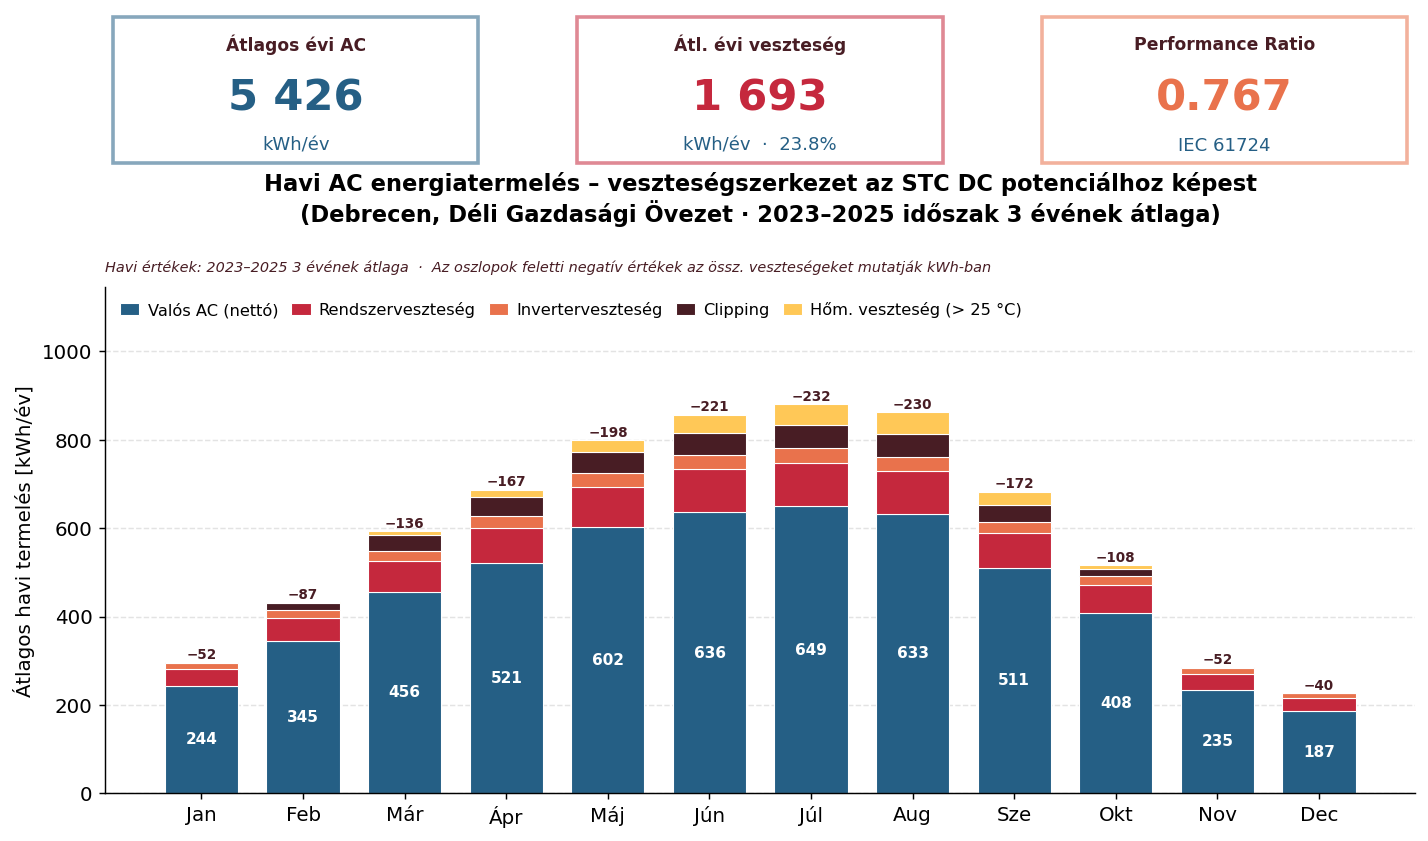

In [15]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from config import LOCATION_NAME, START_DATE, END_DATE, DETAILED_SYSTEM_LOSSES, GAMMA_PDC, TEMP_REF
from pv_calculator import PDC0_TOTAL, PDC0_INV

start_yr, end_yr = START_DATE[:4], END_DATE[:4]
n_years = int(end_yr) - int(start_yr) + 1  # 3 (2023, 2024, 2025)

MONTH_HU = [
    "Jan", "Feb", "Már", "Ápr", "Máj", "Jún",
    "Júl", "Aug", "Sze", "Okt", "Nov", "Dec",
]

from config import C_WATERFALL, C_BASE, MPL_DEFAULTS
plt.rcParams.update(MPL_DEFAULTS)

PDC0_KWP    = PDC0_TOTAL / 1000
derate_live = math.prod(1.0 - v for v in DETAILED_SYSTEM_LOSSES.values())

# ── Óránkénti veszteségkomponensek (adatvezérelten, df_pv-ből) ──────────────
p_ac_net_live = df_pv["p_ac"] * derate_live

# STC DC potenciál: amit a rendszer 25 °C-on termelne (az oszlopok teteje)
p_dc_stc = df_pv["poa_global"] / 1000 * PDC0_TOTAL

# 1. Hőmérsékleti veszteség: STC DC és tényleges DC különbsége
#    Téli hónapokban (temp_cell < TEMP_REF) ez negatív → 0-ra vágva (téli hőnyereség nem látható)
temp_loss_h = (p_dc_stc - df_pv["p_dc"]).clip(lower=0)

# 2. Clipping: p_dc > inverter névleges DC kapacitása (ILR=0.80 → várhatóan ~0)
clipping_h = (df_pv["p_dc"] - PDC0_INV).clip(lower=0)

# 3. Inverterveszteség: DC → AC konverziós veszteség
inverter_loss_h = (df_pv["p_dc"] - clipping_h - df_pv["p_ac"]).clip(lower=0)

# 4. Rendszerveszteség: p_ac → nettó AC (DETAILED_SYSTEM_LOSSES derate)
system_loss_h = (df_pv["p_ac"] - p_ac_net_live).clip(lower=0)

# ── Havi kWh összesítők – n_years-szel osztva → éves átlag ──────────────────
def _monthly_kwh(s):
    return s.groupby(s.index.month).sum() / 1000 / n_years

monthly_kwh_real  = _monthly_kwh(p_ac_net_live)
monthly_sys_loss  = _monthly_kwh(system_loss_h)
monthly_inv_loss  = _monthly_kwh(inverter_loss_h)
monthly_clipping  = _monthly_kwh(clipping_h)
monthly_temp_loss = _monthly_kwh(temp_loss_h)

# ── KPI mutatók (éves átlagok) ────────────────────────────────────────────────
annual_kwh_real       = monthly_kwh_real.sum()          # átlagos évi nettó AC [kWh]
annual_total_loss_kwh = (monthly_sys_loss + monthly_inv_loss
                         + monthly_clipping + monthly_temp_loss).sum()
annual_stc_kwh        = annual_kwh_real + annual_total_loss_kwh
annual_total_loss_pct = annual_total_loss_kwh / annual_stc_kwh * 100
# POA-t is per-éves átlaggá alakítjuk, hogy a PR ne torzuljon
annual_h_poa = df_pv["poa_global"].sum() / 1000 / n_years
annual_pr    = annual_kwh_real / (PDC0_KWP * annual_h_poa)

kpi_data = [
    ("Átlagos évi AC",     f"{annual_kwh_real:,.0f}".replace(",", " "),
     "kWh/év",                                                                       C_WATERFALL["ac"]),
    ("Átl. évi veszteség", f"{annual_total_loss_kwh:,.0f}".replace(",", " "),
     f"kWh/év  ·  {annual_total_loss_pct:.1f}%",                                    C_WATERFALL["loss"]),
    ("Performance Ratio",  f"{annual_pr:.3f}",
     "IEC 61724",                                                                    C_WATERFALL["inv"]),
]

# ── Layout ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 7.8))
gs  = GridSpec(2, 3, figure=fig, height_ratios=[1, 3.2], hspace=0.35, wspace=0.22)

for i, (label, value, unit, color) in enumerate(kpi_data):
    ax_k = fig.add_subplot(gs[0, i])
    ax_k.set_facecolor(C_BASE["bg_light"])
    for sp in ax_k.spines.values():
        sp.set_visible(False)
    ax_k.set_xticks([]); ax_k.set_yticks([])
    ax_k.text(0.5, 0.80, label, ha="center", va="center", fontsize=9.5,
              fontweight="bold", color=C_BASE["neutral_dk"], transform=ax_k.transAxes)
    ax_k.text(0.5, 0.46, value, ha="center", va="center", fontsize=24,
              fontweight="bold", color=color,   transform=ax_k.transAxes)
    ax_k.text(0.5, 0.16, unit,  ha="center", va="center", fontsize=10,
              color=C_BASE["text_lt"],   transform=ax_k.transAxes)
    ax_k.add_patch(plt.Rectangle(
        (0.02, 0.05), 0.96, 0.92, transform=ax_k.transAxes,
        fill=False, edgecolor=color, linewidth=2, alpha=0.55))

# ── Havi stackelt barchart ─────────────────────────────────────────────────────
# Szekvencia alulról felfelé: AC nettó → rendszerveszteség → inverter → clipping → hőmérséklet
SEGMENTS = [
    (monthly_kwh_real,  C_WATERFALL["ac"], "Valós AC (nettó)"),
    (monthly_sys_loss,  C_WATERFALL["loss"], "Rendszerveszteség"),
    (monthly_inv_loss,  C_WATERFALL["inv"], "Inverterveszteség"),
    (monthly_clipping,  C_WATERFALL["clip"], "Clipping"),
    (monthly_temp_loss, C_WATERFALL["temp"], "Hőm. veszteség (> 25 °C)"),
]

width = 0.72
ax    = fig.add_subplot(gs[1, :])
x     = np.arange(1, 13)

bottoms = np.zeros(12)
for data, color, label in SEGMENTS:
    vals = data.values
    bars = ax.bar(x, vals, width, bottom=bottoms,
                  label=label, color=color, edgecolor="white", linewidth=0.6)
    # Zöld szelvény: kWh felirat középre, fehér félkövér
    if label == "Valós AC (nettó)":
        for xi, (v, bot) in enumerate(zip(vals, bottoms)):
            if v > 45:
                ax.text(xi + 1, bot + v / 2, f"{v:.0f}",
                        ha="center", va="center",
                        fontsize=8.5, fontweight="bold", color="white")
    bottoms = bottoms + vals

# Összesített veszteség az oszlopok tetején (STC potenciálhoz képest)
for xi, (top, real) in enumerate(zip(bottoms, monthly_kwh_real.values)):
    total_loss = top - real
    if total_loss > 5:
        ax.text(xi + 1, top + 1.5, f"−{total_loss:.0f}",
                ha="center", va="bottom", fontsize=7.5,
                color=C_BASE["text_dk"], fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(MONTH_HU)
ax.set_ylabel("Átlagos havi termelés [kWh/év]")
ax.set_title(
    f"Havi AC energiatermelés – veszteségszerkezet az STC DC potenciálhoz képest\n"
    f"({LOCATION_NAME} · {start_yr}–{end_yr} időszak {n_years} évének átlaga)",
    fontweight="bold", fontsize=12.5, pad=36)
ax.yaxis.grid(True, alpha=0.35, linestyle="--")
ax.set_axisbelow(True)
ax.legend(frameon=True, facecolor=C_BASE["bg_light"], edgecolor=C_BASE["bg"],
          framealpha=0.95, fontsize=9, ncols=5, loc="upper left",
          handlelength=1.2, handletextpad=0.5, columnspacing=0.8)
ax.text(0.0, 1.030,
        f"Havi értékek: {start_yr}–{end_yr} {n_years} évének átlaga  ·  "
        "Az oszlopok feletti negatív értékek az össz. veszteségeket mutatják kWh-ban",
        transform=ax.transAxes, fontsize=8, color=C_BASE["neutral_dk"], style="italic")
ax.set_ylim(0, bottoms.max() * 1.30)
